Técnicas de Inteligencia Artificial

#Clasificación de imágenes con Redes neuronales y el dataset MNIST



Vamos a clasificar imágenes de dígitos del 0 al 9 escritos a mano utilizando Keras con TensorFlow.

## Descripción de los datos

El dataset que vamos a utilizar es MNIST, una base de datos con imágenes de dígitos escritos a mano. El dataset podréis encontrarlo en : https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz



### Paso 1. Importamos las librerías y cargamos el dataset

In [1]:
from keras.datasets.mnist import load_data
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
mnist = tf.keras.datasets.fashion_mnist

In [3]:
(training_images, training_labels), (test_images, test_labels) = load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


5
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0 

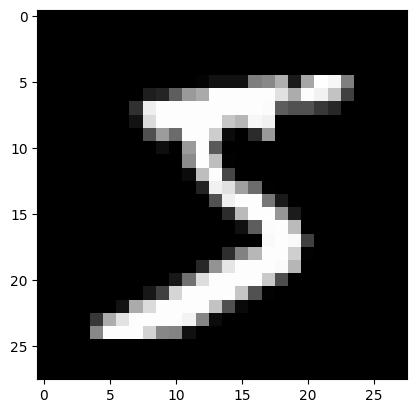

In [4]:
# Vemos el dataset y una imagen de cómo entrena y la etiqueta que usa como clase
import numpy as np
np.set_printoptions(linewidth=200)
plt.imshow(training_images[0], cmap="gray") # recordad que siempre es preferible trabajar en blanco y negro
#
print(training_labels[0])
print(training_images[0])

## Paso 2. Análisis descriptivo de los datos

In [5]:
#Averiguamos cuantas imágenes tenemos paera el entrenamiento. Obtenemos nº de imágenes, tipo de dato y valores de los píxeles en el conjunto de Trainig
print(f"___ Imágenes de training ____")
print(f"Nº de imágenes: {training_images.shape}")
print("Tipo de dato:", training_images.dtype)
print("Valores min/max de los datos:", training_images.min(), training_images.max())

#Obtenemos nº de imágenes, tipo de dato y valores de los píxeles en el conjunto de Test
print(f"\n____ Imágenes de test _____")
print(f"Nº de imágenes: {test_images.shape}")
print("Tipo de dato:", test_images.dtype)
print("Valores min/max de los datos:", test_images.min(), test_images.max())

___ Imágenes de training ____
Nº de imágenes: (60000, 28, 28)
Tipo de dato: uint8
Valores min/max de los datos: 0 255

____ Imágenes de test _____
Nº de imágenes: (10000, 28, 28)
Tipo de dato: uint8
Valores min/max de los datos: 0 255


El conjunto de imágenes de entrenamiento contiene 60.000 imágenes, mientras que el conjunto de test contiene 10.000 imágenes. En ambos casos las imágenes tienen una dimesión de 28x28 pixeles (en escala de grises, ya que en el conjunto de datos no aparece la dimesión asociada al canal de color), con valores enteros (unit8) entre 0 (valor de píxel más oscuro) y 255 (valor de píxel más claro).

Tipo de dato: uint8
Valores min/max de los datos: 0 255


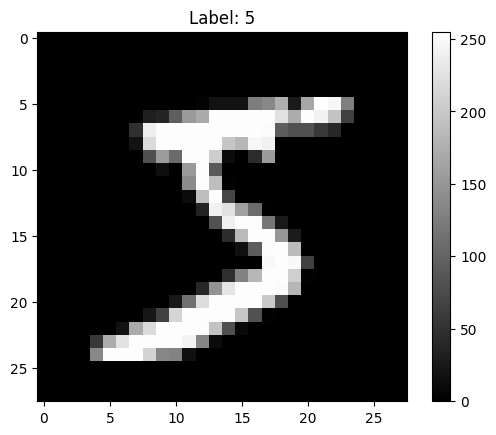

Tipo de dato: uint8
Shape: (60000,)
Clases: [0 1 2 3 4 5 6 7 8 9]
Ejemplo de primera etiqueta: 5


In [6]:
#Exploramos las variables que contienen los datos. Obtenemos tipo de dato y valores de los píxeles en el conjunto de trainig
print("Tipo de dato:", training_images.dtype)
print("Valores min/max de los datos:", training_images.min(), training_images.max())

#Mostramos la primera imagen del conjunto de entrenamiento y su label
plt.imshow(training_images[0], cmap="gray")
plt.title(f"Label: {training_labels[0]}")
plt.colorbar()
plt.show()

#Mostramos la información en este caso asociada a las etiquetas
print(f"Tipo de dato: {training_labels.dtype}")
print(f"Shape: {training_labels.shape}")
print(f"Clases: {np.unique(training_labels)}")
print(f"Ejemplo de primera etiqueta: {training_labels[0]}")

Las imágenes tienen una dimesión de 28x28 pixeles (en escala de grises, ya que en el conjunto de datos no aparece la dimesión asociada al canal de color), con valores enteros (unit8) entre 0 (valor de píxel más oscuro) y 255 (valor de píxel más claro).

Al mostrar por pantalla la imagen situada en la primera posición vemos que se corresponde con un 5. Un poco más abajo, cuando accedemos a la primera de las etiquetas vemos que efectivamente la etiqueta de la primera posición es ese 5 que veíamos en la imagen.

Más allá de eso, en relación a las etiquetas, vemos que el número de etiquetas, como el de las imágenes, es también de 60.000, lo que indica que todas las imágenes están etiquetadas. El valor del dato correspondiente a las Etiquetas es también un entero, pero en este caso en lugar de tener valores entre 0 y 255 (correspondientes a la intensidad de los píxeles) tenemos valores entre 0 y 9, correspondientes a cada uno de los posibles números existentes en las imágenes.

## Paso 3. Normalización y preprocesado de los datos

Se observa que todos los valores numericos están entre 0 y 255. Si estamos entrenando una red neuronal, una buena practica es transformar todos los valores entre 0 y 1: Normalizar

In [7]:
#Normalizamos las imágenes
training_images = training_images / 255.0
test_images = test_images / 255.0

# Comprobamos que los valores estén correctamente normalizados
# Deben estar en el rango [0, 1]
print("Valores mínimo y máximo de training_images:", training_images.min(), training_images.max())

# Mostramos la primera imagen normalizada como una matriz de píxeles
# Cada elemento ahora es un decimal entre 0 y 1
print("Primer ejemplo (matriz de píxeles normalizados):\n", training_images[0])

Valores mínimo y máximo de training_images: 0.0 1.0
Primer ejemplo (matriz de píxeles normalizados):
 [[0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.         0.         0.         0.         0.    

Normalizamos las imágenes. Hemos comprobado que tienen valores entre 0 y 255. Después comprobamos que, una vez normalizadas, los valores posibles se encuentran entre 0 y 1. Por último mostramos por pantalla el resultado de una imagen normalizada.

Esta normalización ayuda a que la red neuronal aprenda más rápido y de manera estable.

In [8]:
#Realizamos el reshape tanto de las imágenes de train como de las de test (el reshape convierte a imagen en un vector de números)
training_images = training_images.reshape(training_images.shape[0], 784)
test_images = test_images.reshape(test_images.shape[0], 784)

#Comprobamos el resultado tras realizar el reshape
print(f"Training images shape: {training_images.shape}")
print(f"Test images shape: {test_images.shape}")

Training images shape: (60000, 784)
Test images shape: (10000, 784)


Una red neuronal no puede recibir de forma directa una imagen, ya que como hemos visto una imagen está formada por una matriz de dos dimensiones (en este caso de 28x28 valores). La capa de entrada de la red neuronal no es bidimensional, si no uinidimensional, por lo que debemos transformar esa imagen en un vector de una única dimension. En este caso como las imágenes son de 28x28 valores hacen un total de 28x28 = 784 valores únicos.

Con reshape lo que conseguimos es esa tranformación, para obtener un vector de entrada de 784 valores adecuado para su procesamiento en la primera capa de la red neuronal.

In [9]:
training_labels = tf.keras.utils.to_categorical(training_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

Muestra cómo son ahora los datos, como resultado de este cambio y también de los realizados en las dos preguntas anteriores. Debate cómo se beneficiará la red neuronal de todos estos cambios.

In [10]:
#  Categorizamos las etiquetas que queremos predecir, es decir, las salidas. Mostramos la primera etiqueta codificada en one-hot_ encoding.
print(training_labels[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Paso 4. Creación del Modelo

Creamos el modelo. Es importante tener en cuenta lo siguientes comandos:

* **Sequential**: Define una SECUENCIA de capas en la red neuronal
* **Dense**: Añade una capa de neuronas
* **Relu**: Es la función de activación. Con Relu:"Si X>0 devuelve X, si no, devuelve 0".
* **Softmax**: toma un conjunto de valores y escoge el mayor.

In [ ]:
#Importamos las librerías necesarias
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#Creamos la estructura de nuestra red neuronal: 512 neuronas, 10 salidas
model1 = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

In [ ]:
#Comprobamos los detalles de la red que acabamos de crear
model1.summary()

In [ ]:
#Compilamos nuestro modelo utilizando categorical_crossentropy como función de pérdida, Adam como optimizador
model1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

La función compile() se encarga de configurar la red neuronal. Es un paso previo necesario antes del entrenamiento.

Los 3 parámetros que hemos configurado son los siguientes:

- optimizer="adam": adam (Adaptive Moment Estimation) es el algoritmo utilizado para actualizar los pesos de la red neuronal con el objetivo de reducir el error detectado.

- loss="categorical_crossentropy": es la función de pérdida emplada para calcular el error entre las predicciones y la etiqueta real.

- metrics=["accuracy"]: es la métrica utilizada para medir el rendimiento en cada epoch. El accurancy se calcula como el porcentaje de muestras clasificadas correctamente.

In [ ]:
#Entrenamos el modelo con fit: 5 epochs, batch_size 32 y validation_split 0,25, previamente compilado usando los datos de entrenamiento

history_1 = model1.fit(
    training_images, training_labels,               # Datos de entrenamiento: imágenes y etiquetas (one-hot)
    validation_split=0.25,  # Datos de validación: se usan para evaluar la red después de cada época
    epochs=5,                      # Número de pasadas completas por todo el dataset
    batch_size=32,                  # Número de muestras que la red procesa antes de actualizar los pesos
    verbose=1                        # Muestra información del entrenamiento: pérdidas y precisión por época
)

In [ ]:
# Modificamos el número de capas ocultas y creamos la estructura de la red neuronal (256 neuronas en la capa oculta y 1024 neuronas en cada una de ellas)
model2 = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

#Compilamos nuestro modelo de acuerdo a los parámetros indicados
model2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

#Entrenamos el modelo configurado y compilado anteriormente usando los datos de entrenamiento

history_2 = model2.fit(
    training_images, training_labels,               # Datos de entrenamiento: imágenes y etiquetas (one-hot)
    validation_split=0.25,  # Datos de validación: se usan para evaluar la red después de cada época
    epochs=5,                      # Número de pasadas completas por todo el dataset
    batch_size=32,                  # Número de muestras que la red procesa antes de actualizar los pesos
    verbose=1                        # Muestra información del entrenamiento: pérdidas y precisión por época
)

In [ ]:
#Creamos la estructura de la red neuronal
model3 = Sequential([
    Dense(1024, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

#Compilamos el modelo
model3.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

#Entrenamos el modelo

history_3 = model3.fit(
    training_images, training_labels,               # Datos de entrenamiento: imágenes y etiquetas (one-hot)
    validation_split=0.25,  # Datos de validación: se usan para evaluar la red después de cada época
    epochs=5,                      # Número de pasadas completas por todo el dataset
    batch_size=32,                  # Número de muestras que la red procesa antes de actualizar los pesos
    verbose=1                        # Muestra información del entrenamiento: pérdidas y precisión por época
)

In [ ]:
#Mostramos las gráficas con la evolución de los resultados obtenidos
plt.figure(figsize=(12, 6))
plt.plot(history_2.history['accuracy'], label='Modelo 2 (256) - Acc Train')
plt.plot(history_1.history['accuracy'], label='Modelo 1 (512) - Acc Train')
plt.plot(history_3.history['accuracy'], label='Modelo 3 (1024) - Acc Train')
plt.plot(history_2.history['val_accuracy'], label='Modelo 2 (256) - Acc Val')
plt.plot(history_1.history['val_accuracy'], label='Modelo 1 (512) - Acc Val')
plt.plot(history_3.history['val_accuracy'], label='Modelo 3 (1024) - Acc Val')
plt.title('Evolución de la precisión durante el entrenamiento y validación')
plt.xlabel('Epochs')
plt.ylabel('Accurancy')
plt.legend()
plt.grid()
plt.show()

In [ ]:
#Mostramos las gráficas con la evolución de los resultados obtenidos
#durante el entrenamiento y validación de cada uno de los modelos
plt.figure(figsize=(12, 6))
plt.plot(history_2.history['loss'], label='Modelo 2 (256) - Loss Train')
plt.plot(history_1.history['loss'], label='Modelo 1 (512) - Loss Train')
plt.plot(history_3.history['loss'], label='Modelo 3 (1024) - Loss Train')
plt.plot(history_2.history['val_loss'], label='Modelo 2 (256) - Loss Val')
plt.plot(history_1.history['val_loss'], label='Modelo 1 (512) - Loss Val')
plt.plot(history_3.history['val_loss'], label='Modelo 3 (1024) - Loss Val')
plt.title('Evolución de la pérdida durante el entrenamiento y validación')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
#Aplicamos early stop. En cada epoch se mide el error de entrenamiento y el de validación. Cuando el de validación no mejora detenemos el entrenamiento (podemos hacerlo estableciendo un val-loos o val-acuraccy)
#Creamos la función de callback durante el entrenamiento para detenerlo cuando se alcance el 98% de precisión en entrenamiento
class myCallback(tf.keras.callbacks.Callback):
      def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')> 0.98):
              print("\nAlcanzado el 98% de precisión, se cancela el entrenamiento!!")
              self.model.stop_training = True

In [ ]:
#Declaramos la función creada anteriormente
callbacks = myCallback()

#Creamos la estructura de nuestra red neuronal
model7 = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

#Compilamos nuestro modelo de acuerdo a los parámetros indicados
model7.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

#Entrenamos el modelo configurado y compilado anteriormente usando los datos de entrenamiento

history_7 = model7.fit(
    training_images, training_labels,               # Datos de entrenamiento: imágenes y etiquetas (one-hot)
    validation_split=0.25,  # Datos de validación: se usan para evaluar la red después de cada época
    epochs=30,                      # Número de pasadas completas por todo el dataset
    batch_size=32,                  # Número de muestras que la red procesa antes de actualizar los pesos
    verbose=1,                       # Muestra información del entrenamiento: pérdidas y precisión por época
    callbacks=[callbacks]             # se pasa la función de callback para detener el entrenamiento cuando se alcance el 85% de precisión en entrenamiento
)

Dada la elevada precisión comprobada en nuestro modelo hemos elevado el umbral de accuracy necesario para que se detenga el entrenamiento. En el entrenamiento vemos que el entrenamiento se detiene tras la tercera epoch al alcanzar el 0.9835 de accuracy en los datos de entrenamiento.